### Middleware

Tightly control what happens inside the agent.
- Tracking agent behaviour -> logging, analytics, debugging
- Adding retries, fallbacks, early termination logic
- Transforming prompts, tool selection, output formatting
- Apply rate limits, gaurdrails, PII detection


In [9]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model

model = init_chat_model(model="llama3.2", model_provider="ollama")
ornith_model = init_chat_model(model="ornith", model_provider="ollama")
model
ornith_model

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, model='ornith')

### Summarization middleware

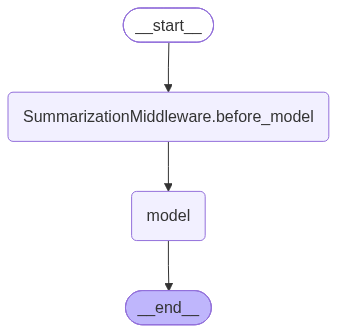

In [16]:
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

agent = create_agent(model=model, checkpointer=InMemorySaver(), middleware=[
    SummarizationMiddleware(model=model,
    trigger=("messages", 2),
    keep=("messages", 2))
])
agent

In [17]:
### Run with thread id
config = {"configurable":{"thread_id":"test-1"}} # uniquely identifies a user

In [18]:
questions = [
    "What is 25 % 5",
    "What is 1 + 1",
    "What is 9 * 7"
]

for q in questions:
    response = agent.invoke({"messages": [HumanMessage(content=q)]}, config)
    print(f'Messages: {response}')
    print(f'Messages: {(len(response["messages"]))}')

Messages: {'messages': [HumanMessage(content='What is 25 % 5', additional_kwargs={}, response_metadata={}, id='bc13ff3a-b692-421f-8d7e-a3de61febffd'), AIMessage(content="To find the remainder when 25% of 5 is divided by 5, we need to calculate 25% of 5 first.\n\n25% = 0.25\n0.25 x 5 = 1.25\n\nNow, let's divide 1.25 by 5:\n\n1.25 ÷ 5 = 0.25\n\nSo the answer is 0.25.", additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-07-24T18:18:27.515733Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7024568791, 'load_duration': 4611274833, 'prompt_eval_count': 32, 'prompt_eval_duration': 117940000, 'eval_count': 85, 'eval_duration': 2261538000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019f9559-87b7-7b11-a1f5-63a0bac290a8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 32, 'output_tokens': 85, 'total_tokens': 117})]}
Messages: 2
Messages: {'messages': [HumanMessage(content='Here is a summary

This can also be done for trigger as "tokens"
make a count_tokens function as a token counter

and then also as fraction where it denotes the context of the model w.r.t the tokens

### Human-In-the-loop Middleware

- Pause execution for human approval, editing or rejecting tool calls before execution


In [32]:
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email(email_id: str):
    """ Reads the emails """
    return f'Email content for id {email_id}'

def send_email(recepient: str, subject: str, body: str):
    """ Sends the emails """
    return f'Email sent to "{recepient}" with subject "{subject}" and body "{body}"'



In [33]:
agent = create_agent(model=ornith_model, tools=[read_email, send_email],
checkpointer=InMemorySaver(),
middleware=[
    HumanInTheLoopMiddleware(interrupt_on={
        "send_email": {
            "allowed_decisions": ["approve", 'edit', "reject"]
        },
        "read_email": False,
    })
]
)

In [34]:
config = {"configurable": {"thread_id": "test-approve"}}

# Step 1: Request

result = agent.invoke({
    "messages": [HumanMessage(content="Send email to john@doe.com with subject 'Hello' and body 'Wazzup!'")]
}, config=config
)

In [35]:
result

{'messages': [HumanMessage(content="Send email to john@doe.com with subject 'Hello' and body 'Wazzup!'", additional_kwargs={}, response_metadata={}, id='3601481a-413a-4129-98dc-d58d56831bf3'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'ornith', 'created_at': '2026-07-26T18:16:25.332774Z', 'done': True, 'done_reason': 'stop', 'total_duration': 20032622416, 'load_duration': 5993752625, 'prompt_eval_count': 423, 'prompt_eval_duration': 3501802000, 'eval_count': 154, 'eval_duration': 10512020000, 'logprobs': None, 'model_name': 'ornith', 'model_provider': 'ollama'}, id='lc_run--019f9fa4-2fb0-7d51-aeda-94e886e3568d-0', tool_calls=[{'name': 'send_email', 'args': {'recepient': 'john@doe.com', 'subject': 'Hello', 'body': 'Wazzup!'}, 'id': '1daa05c4-fcdf-481e-ab23-dd4a2faa61f0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 423, 'output_tokens': 154, 'total_tokens': 577})],
 '__interrupt__': [Interrupt(value={'action_requests': [{'

In [38]:
from langgraph.types import Command
if "__interrupt__" in result:
    print("Paused! Approving...")

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )

    print(f'result: {result["messages"][-1].content}')

Paused! Approving...
result: Done — email sent to john@doe.com with subject "Hello" and body "Wazzup!".


In [39]:
result

{'messages': [HumanMessage(content="Send email to john@doe.com with subject 'Hello' and body 'Wazzup!'", additional_kwargs={}, response_metadata={}, id='3601481a-413a-4129-98dc-d58d56831bf3'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'ornith', 'created_at': '2026-07-26T18:16:25.332774Z', 'done': True, 'done_reason': 'stop', 'total_duration': 20032622416, 'load_duration': 5993752625, 'prompt_eval_count': 423, 'prompt_eval_duration': 3501802000, 'eval_count': 154, 'eval_duration': 10512020000, 'logprobs': None, 'model_name': 'ornith', 'model_provider': 'ollama'}, id='lc_run--019f9fa4-2fb0-7d51-aeda-94e886e3568d-0', tool_calls=[{'name': 'send_email', 'args': {'recepient': 'john@doe.com', 'subject': 'Hello', 'body': 'Wazzup!'}, 'id': '1daa05c4-fcdf-481e-ab23-dd4a2faa61f0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 423, 'output_tokens': 154, 'total_tokens': 577}),
  ToolMessage(content='Email sent to "john@doe.com" with su

In [40]:
agent = create_agent(model=ornith_model, tools=[read_email, send_email],
checkpointer=InMemorySaver(),
middleware=[
    HumanInTheLoopMiddleware(interrupt_on={
        "send_email": {
            "allowed_decisions": ["approve", 'edit', "reject"]
        },
        "read_email": False,
    })
]
)

In [42]:
config = {"configurable": {"thread_id": "test-approve"}}

# Step 1: Request

result = agent.invoke({
    "messages": [HumanMessage(content="Send email to john@doe.com with subject 'Hello' and body 'Wazzup!'")]
}, config=config
)

In [43]:
result

{'messages': [HumanMessage(content="Send email to john@doe.com with subject 'Hello' and body 'Wazzup!'", additional_kwargs={}, response_metadata={}, id='9886adf2-f0eb-422a-824c-24dbbaf63951'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'ornith', 'created_at': '2026-07-26T18:28:09.254774Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11354339833, 'load_duration': 228277958, 'prompt_eval_count': 423, 'prompt_eval_duration': 4853637000, 'eval_count': 90, 'eval_duration': 6246244000, 'logprobs': None, 'model_name': 'ornith', 'model_provider': 'ollama'}, id='lc_run--019f9faf-0f3e-7370-a2c9-cac4e23d1b66-0', tool_calls=[{'name': 'send_email', 'args': {'recepient': 'john@doe.com', 'subject': 'Hello', 'body': 'Wazzup!'}, 'id': '15ebdf17-c10f-497d-b000-1eb89c5efda4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 423, 'output_tokens': 90, 'total_tokens': 513})],
 '__interrupt__': [Interrupt(value={'action_requests': [{'name

In [46]:
from langgraph.types import Command
if "__interrupt__" in result:
    print("Paused! Approving...")

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "edit",
                    "edited_action": {
                        "name": "send_email",
                        "args": {
                            "recepient": "doe@jogn.com",
                            "subject": "Whazzup!",
                            "body": "Yo"
                        }
                    }
                    }
                ]
            }
        ),
        config=config
    )

    print(f'result: {result["messages"][-1].content}')

Paused! Approving...
result: Email sent successfully — it went to **doe@jogn.com** with subject **"Whazzup!"** and body **"Yo"**. Note that this differs from your original request (which was for john@doe.com, "Hello", "Wazzup!") if you meant something else, let me know.


In [47]:
result

{'messages': [HumanMessage(content="Send email to john@doe.com with subject 'Hello' and body 'Wazzup!'", additional_kwargs={}, response_metadata={}, id='9886adf2-f0eb-422a-824c-24dbbaf63951'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'ornith', 'created_at': '2026-07-26T18:28:09.254774Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11354339833, 'load_duration': 228277958, 'prompt_eval_count': 423, 'prompt_eval_duration': 4853637000, 'eval_count': 90, 'eval_duration': 6246244000, 'logprobs': None, 'model_name': 'ornith', 'model_provider': 'ollama'}, id='lc_run--019f9faf-0f3e-7370-a2c9-cac4e23d1b66-0', tool_calls=[{'name': 'send_email', 'args': {'recipient': 'doe@jogn.com', 'subject': 'Whazzup!', 'body': 'Yo'}, 'id': '15ebdf17-c10f-497d-b000-1eb89c5efda4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 423, 'output_tokens': 90, 'total_tokens': 513}),
  ToolMessage(content="Error invoking tool 'send_email' with kwar